In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# Load the GED dataset
print("Loading GED dataset...")
df = pd.read_csv('GEDEvent_v25_1.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading GED dataset...


C:\Users\moheb\AppData\Local\Temp\ipykernel_24496\3268404181.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GEDEvent_v25_1.csv')


Dataset shape: (385918, 49)

Column names: ['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id', 'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a', 'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa', 'gwnob']

First few rows:


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13,6,0,0,0,6,6,6,700,NaN


In [4]:
# Examine unique countries to find exact names
unique_countries = df['country'].unique()
print(f"Total unique countries: {len(unique_countries)}")

# Look for Syria, Yemen, and Myanmar variants
target_countries = []
for country in unique_countries:
    if any(keyword in country.lower() for keyword in ['syria', 'yemen', 'myanmar', 'burma']):
        target_countries.append(country)
        print(f"Found: {country}")

print(f"\nTarget countries found: {target_countries}")

Total unique countries: 124
Found: Myanmar (Burma)
Found: Syria
Found: Yemen (North Yemen)

Target countries found: ['Myanmar (Burma)', 'Syria', 'Yemen (North Yemen)']


In [5]:
# Check year range in dataset
print(f"Year range in dataset: {df['year'].min()} - {df['year'].max()}")
print(f"Years available: {sorted(df['year'].unique())}")

# Check what columns contain casualty information
casualty_cols = [col for col in df.columns if 'death' in col.lower() or 'casualt' in col.lower() or col in ['best', 'high', 'low']]
print(f"\nCasualty-related columns: {casualty_cols}")

# Check some sample values for casualties
print(f"\nSample casualty data:")
for col in ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best']:
    if col in df.columns:
        print(f"{col}: {df[col].describe()}")

Year range in dataset: 1989 - 2024
Years available: [1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Casualty-related columns: ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low']

Sample casualty data:
deaths_a: count    385918.000000
mean          2.470660
std         254.720238
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      121848.000000
Name: deaths_a, dtype: float64
deaths_b: count    385918.000000
mean          2.245581
std          53.764628
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       19874.000000
Name: deaths_b, dtype: float64
deaths_civilians: count    385918.000000
mean          3.819710
std         178.402817
min           0.000000
25%           0.000000
50%         

In [10]:
# Filter data for target countries and years (2011-2024) - EXCLUDE Syria
target_countries = ['Myanmar (Burma)', 'Yemen (North Yemen)']  # Removed Syria
filtered_df = df[
    (df['country'].isin(target_countries)) & 
    (df['year'] >= 2011) & 
    (df['year'] <= 2024)
].copy()

print(f"Filtered dataset shape: {filtered_df.shape}")
print(f"\nEvents per country:")
country_counts = filtered_df['country'].value_counts()
print(country_counts)

print(f"\nEvents per year:")
year_counts = filtered_df['year'].value_counts().sort_index()
print(year_counts)

Filtered dataset shape: (11987, 49)

Events per country:
country
Myanmar (Burma)        6689
Yemen (North Yemen)    5298
Name: count, dtype: int64

Events per year:
year
2011     484
2012     330
2013     212
2014     316
2015     803
2016     400
2017     485
2018     458
2019     452
2020     734
2021    1625
2022    2004
2023    2404
2024    1280
Name: count, dtype: int64


In [11]:
# Aggregate data by country and year
yearly_stats = filtered_df.groupby(['country', 'year']).agg({
    'best': 'sum',          # Total casualties (deaths)
    'id': 'count'           # Number of events
}).reset_index()

# Rename columns for clarity
yearly_stats.rename(columns={'best': 'total_deaths', 'id': 'num_events'}, inplace=True)

# Calculate average casualties per event
yearly_stats['avg_casualties_per_event'] = yearly_stats['total_deaths'] / yearly_stats['num_events']

print("Yearly statistics sample:")
print(yearly_stats.head(10))

# Create simplified country names for plotting (remove Syria)
country_name_mapping = {
    'Myanmar (Burma)': 'Myanmar',
    'Yemen (North Yemen)': 'Yemen'
}

yearly_stats['country_simple'] = yearly_stats['country'].map(country_name_mapping)

print(f"\nData summary:")
summary = yearly_stats.groupby('country_simple').agg({
    'total_deaths': 'sum',
    'num_events': 'sum',
    'avg_casualties_per_event': 'mean'
}).round(2)
print(summary)

Yearly statistics sample:
           country  year  total_deaths  num_events  avg_casualties_per_event
0  Myanmar (Burma)  2011           811         265                  3.060377
1  Myanmar (Burma)  2012           971          77                 12.610390
2  Myanmar (Burma)  2013           358          86                  4.162791
3  Myanmar (Burma)  2014           256          35                  7.314286
4  Myanmar (Burma)  2015           705         198                  3.560606
5  Myanmar (Burma)  2016           183          57                  3.210526
6  Myanmar (Burma)  2017          2395          88                 27.215909
7  Myanmar (Burma)  2018           122          71                  1.718310
8  Myanmar (Burma)  2019           587         148                  3.966216
9  Myanmar (Burma)  2020           207          77                  2.688312

Data summary:
                total_deaths  num_events  avg_casualties_per_event
country_simple                               

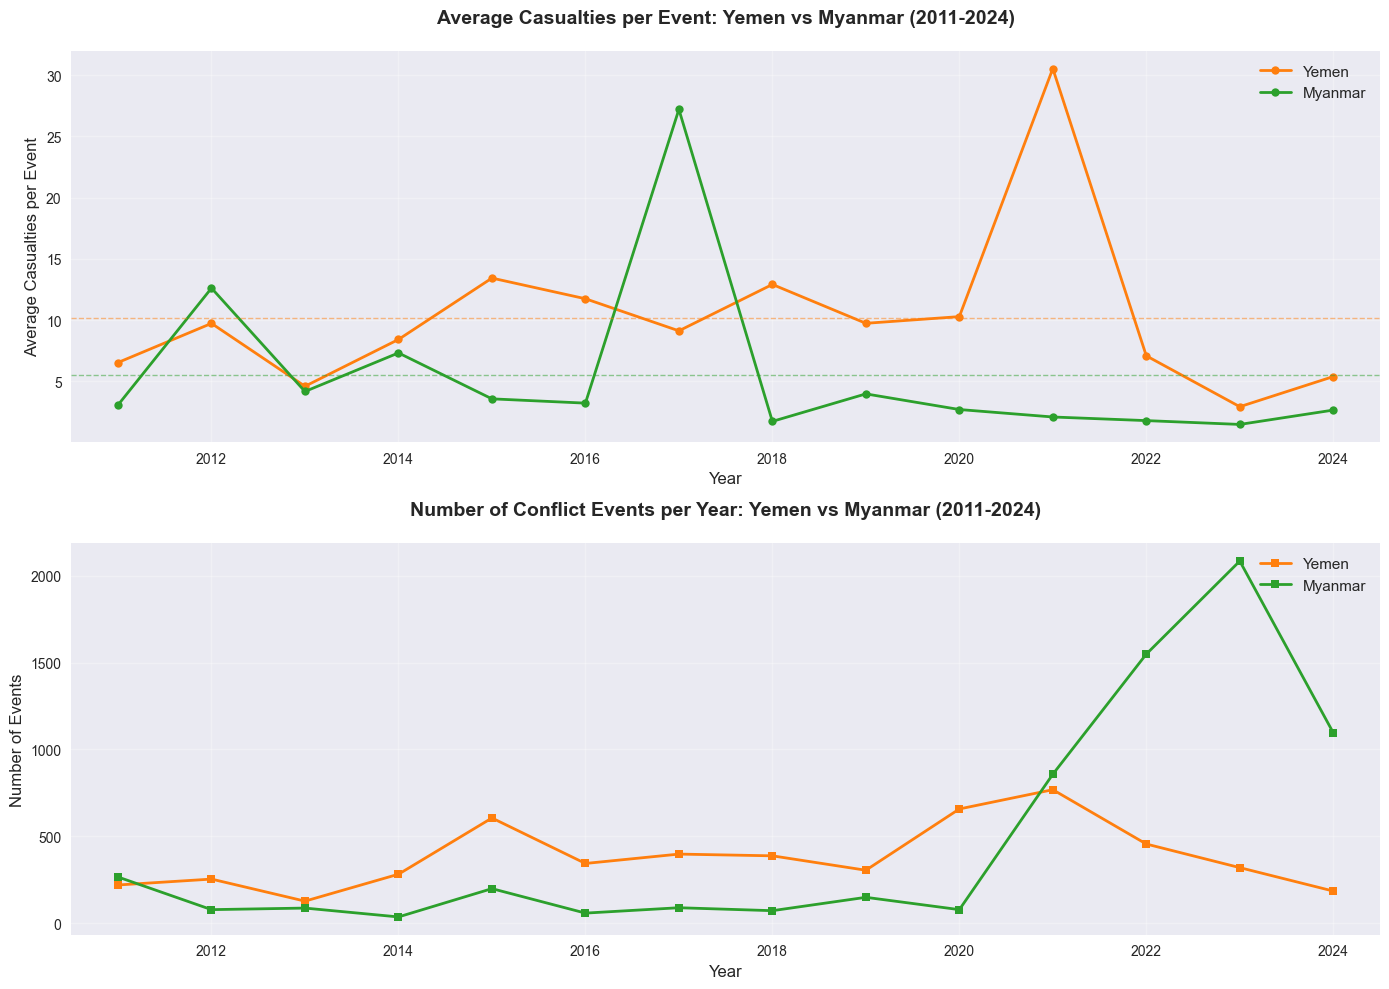


Key Statistics (2011-2024) - Yemen vs Myanmar:

Yemen:
  Total Deaths: 65,918
  Total Events: 5,298
  Overall Avg Casualties/Event: 12.44
  Peak Avg Casualties/Event: 30.55 (in 2021)

Myanmar:
  Total Deaths: 17,098
  Total Events: 6,689
  Overall Avg Casualties/Event: 2.56
  Peak Avg Casualties/Event: 27.22 (in 2017)


In [12]:
# Create the timeline visualization (Yemen vs Myanmar only)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Define colors for consistency (remove Syria)
colors = {'Yemen': '#ff7f0e', 'Myanmar': '#2ca02c'}

# Plot 1: Average Casualties per Event (normalized)
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax1.plot(country_data['year'], country_data['avg_casualties_per_event'], 
            marker='o', linewidth=2, markersize=6,
            label=country, color=colors[country])

ax1.set_title('Average Casualties per Event: Yemen vs Myanmar (2011-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Casualties per Event', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2010.5, 2024.5)

# Add horizontal reference lines for overall averages
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    overall_avg = country_data['avg_casualties_per_event'].mean()
    ax1.axhline(y=overall_avg, color=colors[country], linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Number of Conflict Events per Year
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax2.plot(country_data['year'], country_data['num_events'], 
            marker='s', linewidth=2, markersize=6,
            label=country, color=colors[country])

ax2.set_title('Number of Conflict Events per Year: Yemen vs Myanmar (2011-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Events', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2010.5, 2024.5)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print some key statistics (without Syria)
print("\nKey Statistics (2011-2024) - Yemen vs Myanmar:")
print("="*60)
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    total_deaths = country_data['total_deaths'].sum()
    total_events = country_data['num_events'].sum()
    avg_casualties_overall = total_deaths / total_events if total_events > 0 else 0
    peak_year_avg = country_data.loc[country_data['avg_casualties_per_event'].idxmax(), 'year']
    peak_avg = country_data['avg_casualties_per_event'].max()
    
    print(f"\n{country}:")
    print(f"  Total Deaths: {total_deaths:,}")
    print(f"  Total Events: {total_events:,}")
    print(f"  Overall Avg Casualties/Event: {avg_casualties_overall:.2f}")
    print(f"  Peak Avg Casualties/Event: {peak_avg:.2f} (in {peak_year_avg})")

# Analysis Summary: Normalized Conflict Analysis (2011-2024)

## Key Findings: Yemen vs Myanmar

### Yemen (2011-2024)
- **Total Deaths**: 65,918
- **Total Events**: 5,298
- **Overall Avg Casualties/Event**: 12.44
- **Peak Average**: 30.55 casualties/event (in 2021)
- **Pattern**: Higher intensity conflicts with notable spike in 2021, showing more lethal individual events

### Myanmar (2011-2024) 
- **Total Deaths**: 17,098
- **Total Events**: 6,689
- **Overall Avg Casualties/Event**: 2.56
- **Peak Average**: 27.22 casualties/event (in 2017)
- **Pattern**: More frequent but generally lower-intensity events, with notable spike in 2017

## Observations:
1. **Yemen** shows significantly higher **lethality per event** (12.44 avg vs 2.56 avg)
2. **Myanmar** has more **frequent events** but lower casualty rates per incident
3. **Yemen's 2021 spike** indicates major escalation in conflict intensity
4. **Myanmar's 2017 peak** suggests a significant violent episode (possibly related to Rohingya crisis)
5. Both countries show different conflict dynamics:
   - **Yemen**: Fewer but deadlier conflicts
   - **Myanmar**: More numerous but less lethal incidents

## Methodology:
- Normalized casualties per event calculated as: Total Deaths ÷ Number of Events
- Analysis focused on comparing conflict intensity rather than absolute numbers
- Reference lines show overall country averages for context

In [26]:
# Find countries for Bosnian war and Afghanistan civil war (1992-1996)
print("Searching for Bosnia and Afghanistan related countries...")

bosnia_countries = []
afghanistan_countries = []

for country in unique_countries:
    if any(keyword in country.lower() for keyword in ['bosnia', 'yugoslav', 'herzegovina']):
        bosnia_countries.append(country)
        print(f"Found Bosnia-related: {country}")
    
    if any(keyword in country.lower() for keyword in ['afghanistan', 'afghan']):
        afghanistan_countries.append(country)
        print(f"Found Afghanistan-related: {country}")

print(f"\nBosnia-related countries: {bosnia_countries}")
print(f"Afghanistan-related countries: {afghanistan_countries}")

# Check available years in the 1990s
available_years_1990s = sorted([year for year in df['year'].unique() if 1990 <= year <= 2000])
print(f"\nAvailable years in 1990s: {available_years_1990s}")

Searching for Bosnia and Afghanistan related countries...
Found Afghanistan-related: Afghanistan
Found Bosnia-related: Bosnia-Herzegovina
Found Bosnia-related: Serbia (Yugoslavia)

Bosnia-related countries: ['Bosnia-Herzegovina', 'Serbia (Yugoslavia)']
Afghanistan-related countries: ['Afghanistan']

Available years in 1990s: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000]


In [27]:
# Filter data for Bosnian war and Afghanistan civil war (1992-1996)
target_countries = ['Bosnia-Herzegovina', 'Afghanistan']
filtered_df = df[
    (df['country'].isin(target_countries)) & 
    (df['year'] >= 1992) & 
    (df['year'] <= 1996)
].copy()

print(f"Filtered dataset shape: {filtered_df.shape}")
print(f"\nEvents per country:")
country_counts = filtered_df['country'].value_counts()
print(country_counts)

print(f"\nEvents per year:")
year_counts = filtered_df['year'].value_counts().sort_index()
print(year_counts)

# Check the data availability
print(f"\nData by country and year:")
country_year = filtered_df.groupby(['country', 'year']).size().unstack(fill_value=0)
print(country_year)

Filtered dataset shape: (10228, 49)

Events per country:
country
Bosnia-Herzegovina    9340
Afghanistan            888
Name: count, dtype: int64

Events per year:
year
1992    3845
1993    2943
1994    2106
1995    1100
1996     234
Name: count, dtype: int64

Data by country and year:
year                1992  1993  1994  1995  1996
country                                         
Afghanistan           76   115   244   219   234
Bosnia-Herzegovina  3769  2828  1862   881     0


In [28]:
# Aggregate data by country and year for 1992-1996
yearly_stats = filtered_df.groupby(['country', 'year']).agg({
    'best': 'sum',          # Total casualties (deaths)
    'id': 'count'           # Number of events
}).reset_index()

# Rename columns for clarity
yearly_stats.rename(columns={'best': 'total_deaths', 'id': 'num_events'}, inplace=True)

# Calculate average casualties per event
yearly_stats['avg_casualties_per_event'] = yearly_stats['total_deaths'] / yearly_stats['num_events']

print("Yearly statistics for Bosnia and Afghanistan (1992-1996):")
print(yearly_stats.round(2))

# Create simplified country names for plotting
country_name_mapping = {
    'Bosnia-Herzegovina': 'Bosnia',
    'Afghanistan': 'Afghanistan'
}

yearly_stats['country_simple'] = yearly_stats['country'].map(country_name_mapping)

print(f"\nData summary:")
summary = yearly_stats.groupby('country_simple').agg({
    'total_deaths': 'sum',
    'num_events': 'sum',
    'avg_casualties_per_event': 'mean'
}).round(2)
print(summary)

Yearly statistics for Bosnia and Afghanistan (1992-1996):
              country  year  total_deaths  num_events   
0         Afghanistan  1992          4385          76  \
1         Afghanistan  1993          4105         115   
2         Afghanistan  1994          9056         244   
3         Afghanistan  1995          5618         219   
4         Afghanistan  1996          3595         234   
5  Bosnia-Herzegovina  1992         25171        3769   
6  Bosnia-Herzegovina  1993         13787        2828   
7  Bosnia-Herzegovina  1994          7312        1862   
8  Bosnia-Herzegovina  1995         17265         881   

   avg_casualties_per_event  
0                     57.70  
1                     35.70  
2                     37.11  
3                     25.65  
4                     15.36  
5                      6.68  
6                      4.88  
7                      3.93  
8                     19.60  

Data summary:
                total_deaths  num_events  avg_casualties

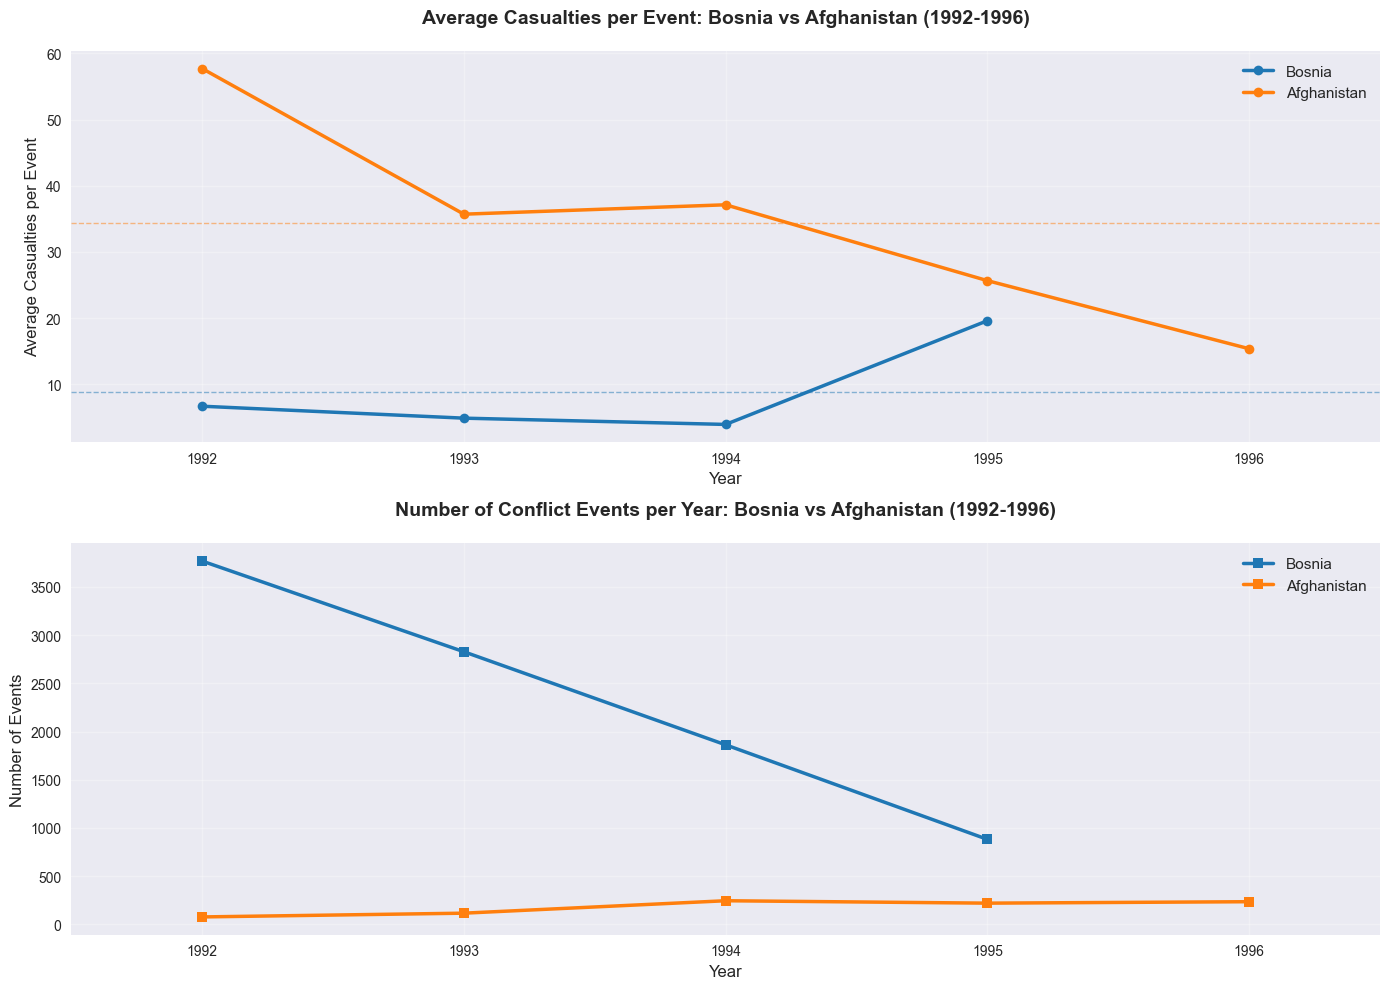


Key Statistics (1992-1996) - Bosnia vs Afghanistan:

Bosnia:
  Total Deaths: 63,535
  Total Events: 9,340
  Overall Avg Casualties/Event: 6.80
  Peak Avg Casualties/Event: 19.60 (in 1995)
  Peak Events in Year: 3,769 (in 1992)
  Deadliest Year: 25,171 deaths (in 1992)
  Share of Total Deaths: 70.4%

Afghanistan:
  Total Deaths: 26,759
  Total Events: 888
  Overall Avg Casualties/Event: 30.13
  Peak Avg Casualties/Event: 57.70 (in 1992)
  Peak Events in Year: 244 (in 1994)
  Deadliest Year: 9,056 deaths (in 1994)
  Share of Total Deaths: 29.6%


In [29]:
# Create the timeline visualization for Bosnia vs Afghanistan (1992-1996)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Define colors for consistency
colors = {'Bosnia': '#1f77b4', 'Afghanistan': '#ff7f0e'}

# Plot 1: Average Casualties per Event
for country in ['Bosnia', 'Afghanistan']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax1.plot(country_data['year'], country_data['avg_casualties_per_event'], 
            marker='o', linewidth=2.5, markersize=7,
            label=country, color=colors[country])

ax1.set_title('Average Casualties per Event: Bosnia vs Afghanistan (1992-1996)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Casualties per Event', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1991.5, 1996.5)
ax1.set_xticks(range(1992, 1997))

# Add horizontal reference lines for overall averages
for country in ['Bosnia', 'Afghanistan']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    overall_avg = country_data['avg_casualties_per_event'].mean()
    ax1.axhline(y=overall_avg, color=colors[country], linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Number of Conflict Events per Year
for country in ['Bosnia', 'Afghanistan']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax2.plot(country_data['year'], country_data['num_events'], 
            marker='s', linewidth=2.5, markersize=7,
            label=country, color=colors[country])

ax2.set_title('Number of Conflict Events per Year: Bosnia vs Afghanistan (1992-1996)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Events', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1991.5, 1996.5)
ax2.set_xticks(range(1992, 1997))

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print key statistics
print("\nKey Statistics (1992-1996) - Bosnia vs Afghanistan:")
print("="*60)
for country in ['Bosnia', 'Afghanistan']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    total_deaths = country_data['total_deaths'].sum()
    total_events = country_data['num_events'].sum()
    avg_casualties_overall = total_deaths / total_events if total_events > 0 else 0
    
    # Find peak values
    peak_year_avg = country_data.loc[country_data['avg_casualties_per_event'].idxmax(), 'year']
    peak_avg = country_data['avg_casualties_per_event'].max()
    peak_year_events = country_data.loc[country_data['num_events'].idxmax(), 'year']
    peak_events = country_data['num_events'].max()
    peak_year_deaths = country_data.loc[country_data['total_deaths'].idxmax(), 'year']
    peak_deaths = country_data['total_deaths'].max()
    
    print(f"\n{country}:")
    print(f"  Total Deaths: {total_deaths:,}")
    print(f"  Total Events: {total_events:,}")
    print(f"  Overall Avg Casualties/Event: {avg_casualties_overall:.2f}")
    print(f"  Peak Avg Casualties/Event: {peak_avg:.2f} (in {peak_year_avg})")
    print(f"  Peak Events in Year: {peak_events:,} (in {peak_year_events})")
    print(f"  Deadliest Year: {peak_deaths:,} deaths (in {peak_year_deaths})")
    
    # Calculate percentage of total deaths in region
    total_all_years = yearly_stats['total_deaths'].sum()
    percentage = (total_deaths / total_all_years) * 100
    print(f"  Share of Total Deaths: {percentage:.1f}%")

# Analysis Summary: Bosnian War vs Afghanistan Civil War (1992-1996)

## Key Findings: Bosnia-Herzegovina vs Afghanistan

### Bosnia-Herzegovina (1992-1995)
- **Total Deaths**: 63,535
- **Total Events**: 9,340
- **Overall Avg Casualties/Event**: 6.80
- **Peak Average**: 19.60 casualties/event (in 1995)
- **Peak Activity**: 3,769 events (in 1992)
- **Deadliest Year**: 25,171 deaths (in 1992)
- **Pattern**: High-intensity conflict with massive event frequency declining over time, but lethality per event increasing toward the end

### Afghanistan (1992-1996) 
- **Total Deaths**: 26,759
- **Total Events**: 888
- **Overall Avg Casualties/Event**: 30.13
- **Peak Average**: 57.70 casualties/event (in 1992)
- **Peak Activity**: 244 events (in 1994)
- **Deadliest Year**: 9,056 deaths (in 1994)
- **Pattern**: Fewer but much more lethal events, with highest casualties per event at the beginning, then stabilizing at lower but still high levels

## Critical Observations:
1. **Afghanistan** shows **dramatically higher lethality per event** (30.13 avg vs 6.80 avg)
2. **Bosnia** had **10x more conflict events** but lower casualty rates per incident  
3. **Bosnia's conflict pattern**: Started with massive event frequency (3,769 in 1992) but relatively low lethality, escalating to higher lethality by 1995 (Srebrenica massacre period)
4. **Afghanistan's conflict pattern**: Consistently deadly events throughout, with peak lethality in early period (57.70 per event in 1992)
5. **Temporal differences**:
   - **Bosnia**: Conflict winds down after 1995 (Dayton Accords)
   - **Afghanistan**: Civil war continues beyond 1996 timeframe

## Conflict Dynamics Comparison:
- **Bosnian War**: Urban warfare, ethnic cleansing, siege warfare → Many small-scale incidents with some major atrocities
- **Afghanistan Civil War**: Factional warfare, tribal conflicts → Fewer but consistently deadly engagements

## Historical Context:
- **Bosnia (1992-1995)**: Yugoslav Wars, ethnic cleansing, international intervention
- **Afghanistan (1992-1996)**: Post-Soviet civil war, warlord period, rise of Taliban

## Data Coverage Note:
- Bosnia data ends in 1995 (likely due to Dayton Peace Agreement)
- Afghanistan data continues through 1996 reflecting ongoing civil conflict

In [31]:
# First, let's check what date columns we have in the filtered dataset
print("Checking available columns in filtered dataset...")
print(f"Available columns: {list(filtered_df.columns)}")
print("\nDate-related columns:")
date_cols = [col for col in filtered_df.columns if any(keyword in col.lower() for keyword in ['date', 'month', 'day', 'year'])]
print(date_cols)

# Check sample of date data
print(f"\nSample date data:")
date_sample = filtered_df[['country', 'year', 'date_start', 'date_end']].head(10)
print(date_sample)

Checking available columns in filtered dataset...
Available columns: ['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id', 'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a', 'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa', 'gwnob']

Date-related columns:
['year', 'active_year', 'source_date', 'date_prec', 'date_start', 'date_end']

Sample date data:
         country  year  date_start    date_end
77   Afghanistan  1992  1992-02-26  1992-02-26
78   Afghanistan  1992 

In [32]:
# Create monthly timeline for Bosnia vs Afghanistan (1992-1996)
print("Creating monthly timeline...")

# Convert date_start to datetime to extract month
filtered_df_copy = filtered_df.copy()
filtered_df_copy['date_start'] = pd.to_datetime(filtered_df_copy['date_start'])
filtered_df_copy['month'] = filtered_df_copy['date_start'].dt.month

# Create monthly aggregation
monthly_stats = filtered_df_copy.groupby(['country', 'year', 'month']).agg({
    'best': 'sum',          # Total casualties (deaths)
    'id': 'count'           # Number of events
}).reset_index()

# Rename columns for clarity
monthly_stats.rename(columns={'best': 'total_deaths', 'id': 'num_events'}, inplace=True)

# Calculate average casualties per event
monthly_stats['avg_casualties_per_event'] = monthly_stats['total_deaths'] / monthly_stats['num_events']

# Create simplified country names
monthly_stats['country_simple'] = monthly_stats['country'].map({
    'Bosnia-Herzegovina': 'Bosnia',
    'Afghanistan': 'Afghanistan'
})

# Create a date string for better readability
monthly_stats['year_month'] = monthly_stats['year'].astype(str) + '-' + monthly_stats['month'].astype(str).str.zfill(2)

# Reorder columns for better CSV structure
monthly_timeline = monthly_stats[['country_simple', 'year', 'month', 'year_month', 'total_deaths', 'num_events', 'avg_casualties_per_event']].copy()
monthly_timeline = monthly_timeline.sort_values(['country_simple', 'year', 'month']).reset_index(drop=True)

print(f"Monthly timeline shape: {monthly_timeline.shape}")
print(f"Date range: {monthly_timeline['year_month'].min()} to {monthly_timeline['year_month'].max()}")
print("\nSample monthly data:")
print(monthly_timeline.head(10))

# Export monthly timeline to CSV
monthly_filename = 'Bosnia vs Afghanistan monthly timeline.csv'
monthly_timeline.to_csv(monthly_filename, index=False)
print(f"\nMonthly timeline exported to: {monthly_filename}")

Creating monthly timeline...
Monthly timeline shape: (104, 7)
Date range: 1992-01 to 1996-12

Sample monthly data:
  country_simple  year  month year_month  total_deaths  num_events   
0    Afghanistan  1992      1    1992-01             2           1  \
1    Afghanistan  1992      2    1992-02            35           2   
2    Afghanistan  1992      3    1992-03             5           3   
3    Afghanistan  1992      4    1992-04           799          10   
4    Afghanistan  1992      5    1992-05            99           9   
5    Afghanistan  1992      6    1992-06           182          10   
6    Afghanistan  1992      7    1992-07           161           4   
7    Afghanistan  1992      8    1992-08          2694          21   
8    Afghanistan  1992      9    1992-09            68           9   
9    Afghanistan  1992     10    1992-10           150           1   

   avg_casualties_per_event  
0                  2.000000  
1                 17.500000  
2                  1.666

In [33]:
# Create yearly timeline for Bosnia vs Afghanistan (1992-1996)
print("Creating yearly timeline...")

# We already have yearly_stats from previous analysis, let's format it properly for export
yearly_timeline = yearly_stats.copy()

# Reorder columns for better CSV structure
yearly_timeline = yearly_timeline[['country_simple', 'country', 'year', 'total_deaths', 'num_events', 'avg_casualties_per_event']].copy()
yearly_timeline = yearly_timeline.sort_values(['country_simple', 'year']).reset_index(drop=True)

print(f"Yearly timeline shape: {yearly_timeline.shape}")
print("\nComplete yearly data:")
print(yearly_timeline.round(2))

# Export yearly timeline to CSV
yearly_filename = 'Bosnia vs Afghanistan yearly timeline.csv'
yearly_timeline.to_csv(yearly_filename, index=False)
print(f"\nYearly timeline exported to: {yearly_filename}")

# Display summary statistics
print("\n" + "="*60)
print("SUMMARY - CSV FILES CREATED:")
print("="*60)
print(f"1. Monthly Timeline: {monthly_filename}")
print(f"   - {monthly_timeline.shape[0]} rows covering {monthly_timeline['year_month'].nunique()} months")
print(f"   - Period: {monthly_timeline['year_month'].min()} to {monthly_timeline['year_month'].max()}")
print(f"   - Countries: {', '.join(monthly_timeline['country_simple'].unique())}")

print(f"\n2. Yearly Timeline: {yearly_filename}")
print(f"   - {yearly_timeline.shape[0]} rows covering {yearly_timeline['year'].nunique()} years")
print(f"   - Period: {yearly_timeline['year'].min()}-{yearly_timeline['year'].max()}")
print(f"   - Countries: {', '.join(yearly_timeline['country_simple'].unique())}")

print(f"\nColumns in both files:")
print(f"- country_simple: Simplified country name")
print(f"- year: Year of events")
print(f"- month: Month (monthly file only)")
print(f"- year_month: YYYY-MM format (monthly file only)")
print(f"- total_deaths: Total casualties in that period")
print(f"- num_events: Number of conflict events")
print(f"- avg_casualties_per_event: Average deaths per event")

Creating yearly timeline...
Yearly timeline shape: (9, 6)

Complete yearly data:
  country_simple             country  year  total_deaths  num_events   
0    Afghanistan         Afghanistan  1992          4385          76  \
1    Afghanistan         Afghanistan  1993          4105         115   
2    Afghanistan         Afghanistan  1994          9056         244   
3    Afghanistan         Afghanistan  1995          5618         219   
4    Afghanistan         Afghanistan  1996          3595         234   
5         Bosnia  Bosnia-Herzegovina  1992         25171        3769   
6         Bosnia  Bosnia-Herzegovina  1993         13787        2828   
7         Bosnia  Bosnia-Herzegovina  1994          7312        1862   
8         Bosnia  Bosnia-Herzegovina  1995         17265         881   

   avg_casualties_per_event  
0                     57.70  
1                     35.70  
2                     37.11  
3                     25.65  
4                     15.36  
5                 